In [145]:
import numpy as np
import matplotlib.pyplot as plt
import torch.nn as nn
import torch
import scipy.stats as stats

In [226]:
S_0 = 10
T = 1
M = 100
N = 50

In [227]:
S = np.zeros(shape=(M+1,N))
S[0,:] = S_0
dt = T/M
for t in range(1,M+1):
    S[t,:] = S[t-1,:]+np.sqrt(dt)*np.random.normal(0,1,N)


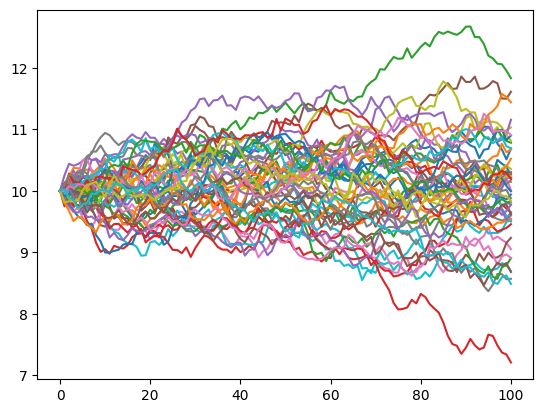

In [228]:
plt.plot(S)
plt.show()

In [229]:
epochs = 100
batch_size = int(N/10)
lamb = 1e-5
loss_fn = nn.MSELoss()
x0 = 0
K = 10
eta = 1e-3
def g(x,K):
    return np.maximum(x-K,0)


In [230]:
Phi = []
for _ in range(1,M+1):
    Phi.append(nn.Sequential(
        nn.Linear(2*_+1,16),
        nn.ReLU(),
        nn.Linear(16,16),
        nn.ReLU(),
        nn.Linear(16,1)
        ).double())
    
opts = []
for _ in range(M):
    opts.append(torch.optim.Adam(Phi[_].parameters(),lr=eta))

In [231]:
print(Phi[1])
print(opts[1])

Sequential(
  (0): Linear(in_features=5, out_features=16, bias=True)
  (1): ReLU()
  (2): Linear(in_features=16, out_features=16, bias=True)
  (3): ReLU()
  (4): Linear(in_features=16, out_features=1, bias=True)
)
Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.001
    maximize: False
    weight_decay: 0
)


In [232]:
loss_l = []

In [233]:
for e in range(1,epochs+1):
    order = torch.randperm(N)
    for b in range(0,N,batch_size):
        for opt in opts:
            opt.zero_grad()
        L = 0

        for i in order[b:b+batch_size]:
            W = [torch.tensor([x0],dtype=torch.float64)]
            for j in range(M):
                t = dt*j
                I = torch.cat((torch.tensor([t],dtype=torch.float64),
                               torch.cat(W),
                               torch.from_numpy(S[0:j+1,i])))
                alpha_t = Phi[j](I)
                W_t = W[-1]+alpha_t*(S[j,i]-S[j-1,i])
                W.append(W_t)
                theta = torch.nn.utils.parameters_to_vector(Phi[j].parameters())

            L = L+loss_fn(torch.tensor([g(S[j,i],K)]),W_t)+lamb*torch.norm(theta,p=2)**2
        L = L/batch_size
        loss_l.append(L.detach())
        L.backward()
        for opt in opts:
            opt.step()

    if e%10 == 0:
        print(f"{e},{loss_l[e]}")



10,0.27505109519294024
20,0.2767195165957839
30,0.03432114134666322
40,0.04203976765473215
50,0.027892178457387763
60,0.015141455171103218
70,0.021721330877872445
80,0.0061514015238805135
90,0.005325335400344326
100,0.001953377655184091


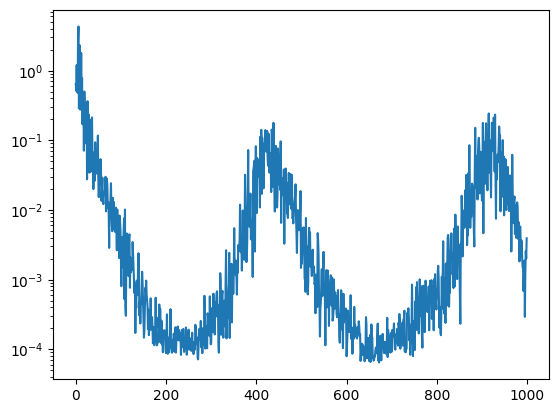

In [234]:
plt.plot(loss_l)
plt.yscale("log")
plt.show()

In [235]:
def tr(sigma,K,S,T,dt,j):
    t = j*dt
    def d1(sigma,K,S,T,t):
        return (np.log(S/K)+0.5*sigma**2 *(T-t))/(sigma*np.sqrt(T-t))

    return -stats.norm.cdf(-d1(sigma,K,S,T,t))

In [236]:
alphas = np.zeros(shape=(N,M))
true_alpha = np.zeros(shape=(N,M))
for i in range(N):
    W = [torch.tensor([x0],dtype=torch.float64)]
    for j in range(M):
        t = dt*j
        I = torch.cat((torch.tensor([t],dtype=torch.float64),
                        torch.cat(W),
                        torch.from_numpy(S[0:j+1,i])))
        alpha_t = Phi[j](I)
        alphas[i,j]=(alpha_t.detach())
        W_t = W[-1]+alpha_t*(S[j,i]-S[j-1,i])
        W.append(W_t)

        true_alpha[i,j] = tr(0.2,K,S[j,i],T,dt,j)


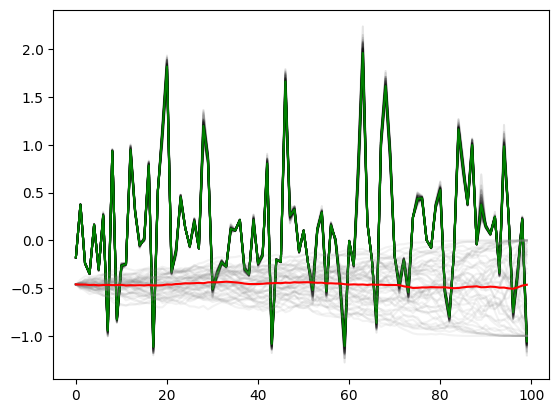

In [237]:
plt.plot(alphas.T,color="black",alpha=0.1)
plt.plot(np.mean(alphas,axis=0),color="green")
plt.plot(true_alpha.T,color="grey",alpha=0.1)
plt.plot(np.mean(true_alpha,axis=0),color="red")
plt.plot()
plt.show()